In [5]:
# Cell 1: Imports, Setup, and Dataset Preprocessing
import os
import glob
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import kagglehub

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Dataset Download & Selection (HAM10000 as base) ---
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
metadata_csv_path = next((f for f in csv_files if 'metadata' in os.path.basename(f)), None)

df = pd.read_csv(metadata_csv_path)
df.columns = df.columns.str.strip().str.lower()
all_image_paths = glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)
image_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_paths}

df['path'] = df['image_id'].map(image_path_dict)
df = df.dropna(subset=['path']).reset_index(drop=True)

# Select top 3 classes for clear visual and classification comparison
top_classes = df['dx'].value_counts().nlargest(3).index.tolist()
df_subset = df[df['dx'].isin(top_classes)].copy()
label_mapping = {label: idx for idx, label in enumerate(top_classes)}
df_subset['label'] = df_subset['dx'].map(label_mapping)

print(f"Selected Classes: {top_classes}")
print(f"Total Selected Images: {len(df_subset)}")

Using device: cuda
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Selected Classes: ['nv', 'mel', 'bkl']
Total Selected Images: 8917


# **Task 1: Comparative Edge Detection**

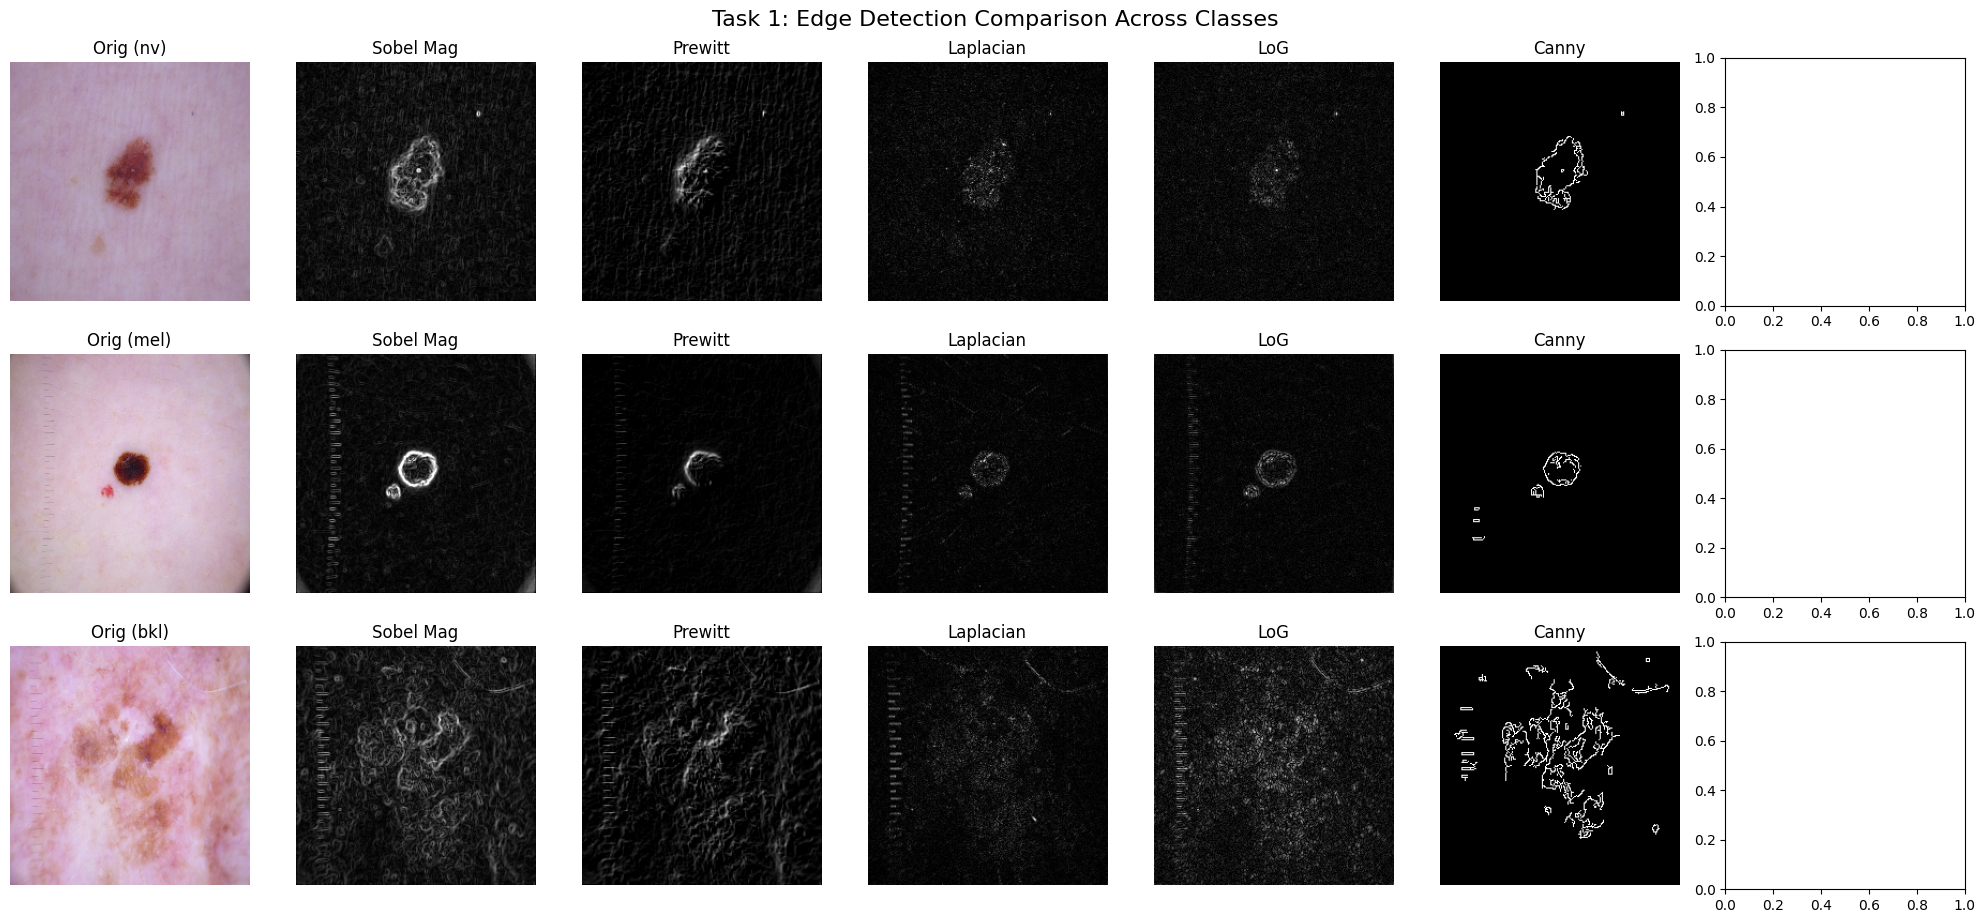

In [6]:
# Cell 2: Task 1 - Comparative Edge Detection
def get_edge_maps(img_gray):
    # 1. Sobel Gx, Gy, Magnitude
    sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_mag = np.uint8(np.clip(sobel_mag, 0, 255))

    # 2. Prewitt
    kernelx = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=int)
    kernely = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=int)
    prewitt_x = cv2.filter2D(img_gray, -1, kernelx)
    prewitt_y = cv2.filter2D(img_gray, -1, kernely)
    prewitt_mag = cv2.addWeighted(cv2.convertScaleAbs(prewitt_x), 0.5, cv2.convertScaleAbs(prewitt_y), 0.5, 0)

    # 3. Laplacian
    laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)
    laplacian = np.uint8(np.absolute(laplacian))

    # 4. Laplacian of Gaussian (LoG)
    blurred = cv2.GaussianBlur(img_gray, (3, 3), 0)
    log_img = cv2.Laplacian(blurred, cv2.CV_64F)
    log_img = np.uint8(np.absolute(log_img))

    # 5. Canny
    canny_img = cv2.Canny(img_gray, 50, 150)

    return {
        "Sobel Gx": np.uint8(np.absolute(sobel_x)),
        "Sobel Gy": np.uint8(np.absolute(sobel_y)),
        "Sobel Mag": sobel_mag,
        "Prewitt": prewitt_mag,
        "Laplacian": laplacian,
        "LoG": log_img,
        "Canny": canny_img
    }

# Plot Task 1 Required Figure (3 Classes)
fig, axes = plt.subplots(len(top_classes), 7, figsize=(20, 9))
for i, cls_name in enumerate(top_classes):
    sample_path = df_subset[df_subset['dx'] == cls_name]['path'].iloc[0]
    img = cv2.imread(sample_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.resize(img_gray, (224, 224))

    edges = get_edge_maps(img_gray)
    display_keys = ["Sobel Mag", "Prewitt", "Laplacian", "LoG", "Canny"]

    axes[i, 0].imshow(cv2.cvtColor(cv2.resize(img, (224, 224)), cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Orig ({cls_name})")
    axes[i, 0].axis('off')

    for j, key in enumerate(display_keys):
        axes[i, j+1].imshow(edges[key], cmap='gray')
        axes[i, j+1].set_title(key)
        axes[i, j+1].axis('off')

plt.tight_layout()
plt.suptitle("Task 1: Edge Detection Comparison Across Classes", y=1.02, fontsize=16)
plt.show()

# **Task 2: Effect of Noise on Edge Detection**

In [7]:
# Cell 3: Task 2 - Noise Generation & Table 1 Populator
def add_gaussian_noise(image, mean=0, var=0.01):
    sigma = var ** 0.5
    gauss = np.random.normal(mean, sigma, image.shape) * 255
    noisy = np.clip(image.astype(np.float32) + gauss, 0, 255)
    return noisy.astype(np.uint8)

def add_salt_and_pepper_noise(image, salt_prob=0.02, pepper_prob=0.02):
    noisy = np.copy(image)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

table1_rows = [
    {"Detector": "Sobel", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "None"},
    {"Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "None"},
    {"Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Salt & Pepper", "Preprocessing": "None"},
    {"Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "Gaussian Filter"},
    {"Detector": "Sobel", "Input Image": "Noisy", "Noise Type": "Salt & Pepper", "Preprocessing": "Median Filter"},
    {"Detector": "Prewitt", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "None"},
    {"Detector": "Laplacian", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "None"},
    {"Detector": "LoG", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "Gaussian Filter (Built-in)"},
    {"Detector": "Canny", "Input Image": "Original", "Noise Type": "None", "Preprocessing": "Smoothing"},
    {"Detector": "Canny", "Input Image": "Noisy", "Noise Type": "Gaussian", "Preprocessing": "Gaussian Filter"},
    {"Detector": "Canny", "Input Image": "Noisy", "Noise Type": "Salt & Pepper", "Preprocessing": "Median Filter"},
]

sample_img_path = df_subset['path'].iloc[0]
orig_gray = cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2GRAY)
orig_gray = cv2.resize(orig_gray, (224, 224))

processed_table1 = []
for row in table1_rows:
    img = orig_gray.copy()
    if row["Noise Type"] == "Gaussian":
        img = add_gaussian_noise(img)
    elif row["Noise Type"] == "Salt & Pepper":
        img = add_salt_and_pepper_noise(img)

    if row["Preprocessing"] == "Gaussian Filter":
        img = cv2.GaussianBlur(img, (5, 5), 0)
    elif row["Preprocessing"] == "Median Filter":
        img = cv2.medianBlur(img, 5)

    det = row["Detector"]
    if det == "Sobel":
        edge = get_edge_maps(img)["Sobel Mag"]
    elif det == "Prewitt":
        edge = get_edge_maps(img)["Prewitt"]
    elif det == "Laplacian":
        edge = get_edge_maps(img)["Laplacian"]
    elif det == "LoG":
        edge = get_edge_maps(img)["LoG"]
    elif det == "Canny":
        edge = get_edge_maps(img)["Canny"]

    edge_pct = (np.count_nonzero(edge) / edge.size) * 100
    row_data = row.copy()
    row_data["Edge Quality"] = "High" if edge_pct < 15 else ("Moderate" if edge_pct < 30 else "Low (Noisy)")
    row_data["Noise Sensitivity"] = "High" if row["Noise Type"] != "None" and row["Preprocessing"] == "None" else "Low/Mitigated"
    row_data["Observations"] = f"Detected edges: {edge_pct:.1f}% density. " + ("Smoothing reduced false edges." if "Filter" in row["Preprocessing"] else "Unfiltered noise created false edges.")
    processed_table1.append(row_data)

df_table1 = pd.DataFrame(processed_table1)
print("--- Table 1: Effect of Noise and Preprocessing on Edge Detection ---")
display(df_table1)

--- Table 1: Effect of Noise and Preprocessing on Edge Detection ---


,Detector,Input Image,Noise Type,Preprocessing,Edge Quality,Noise Sensitivity,Observations
0,Sobel,Original,None,None,Low (Noisy),Low/Mitigated,Detected edges: 99.8% density. Unfiltered nois...
1,Sobel,Noisy,Gaussian,None,Low (Noisy),High,Detected edges: 100.0% density. Unfiltered noi...
2,Sobel,Noisy,Salt & Pepper,None,Low (Noisy),High,Detected edges: 99.8% density. Unfiltered nois...
3,Sobel,Noisy,Gaussian,Gaussian Filter,Low (Noisy),Low/Mitigated,Detected edges: 99.9% density. Smoothing reduc...
4,Sobel,Noisy,Salt & Pepper,Median Filter,Low (Noisy),Low/Mitigated,Detected edges: 98.7% density. Smoothing reduc...
5,Prewitt,Original,None,None,Low (Noisy),Low/Mitigated,Detected edges: 68.3% density. Unfiltered nois...
6,Laplacian,Original,None,None,Low (Noisy),Low/Mitigated,Detected edges: 95.0% density. Unfiltered nois...
7,LoG,Noisy,Gaussian,Gaussian Filter (Built-in),Low (Noisy),Low/Mitigated,Detected edges: 97.6% density. Smoothing reduc...
8,Canny,Original,None,Smoothing,High,Low/Mitigated,Detected edges: 4.2% density. Unfiltered noise...
9,Canny,Noisy,Gaussian,Gaussian Filter,High,Low/Mitigated,Detected edges: 7.6% density. Smoothing reduce...


# **Task 3: Parameter Analysis of Canny Edge Detection**

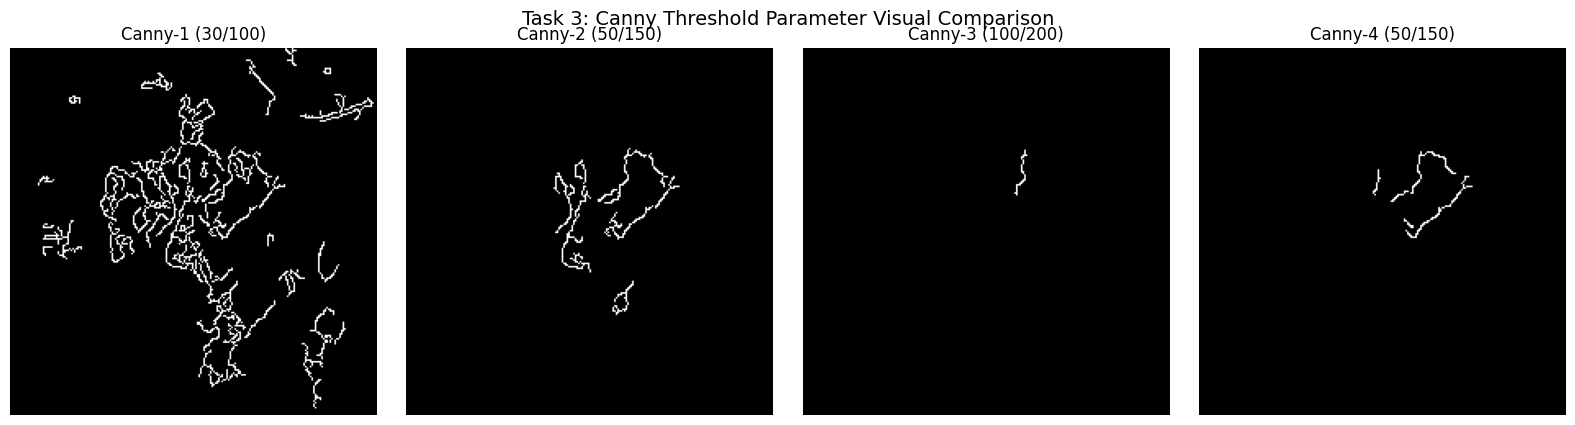

--- Table 2: Canny Parameter Analysis ---


,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges,Observations
0,Canny-1,30,100,3x3,Too Noisy,2462,Excessive fine noise.
1,Canny-2,50,150,3x3,Optimal Detail,517,Good balance of continuous edges.
2,Canny-3,100,200,3x3,Sparse Edges,38,Missing weak boundaries.
3,Canny-4,50,150,5x5,Sparse Edges,192,Missing weak boundaries.


In [8]:
# Cell 4: Task 3 - Parameter Analysis of Canny Edge Detection
canny_configs = [
    {"Config": "Canny-1", "Low": 30, "High": 100, "Kernel Size": "3x3"},
    {"Config": "Canny-2", "Low": 50, "High": 150, "Kernel Size": "3x3"},
    {"Config": "Canny-3", "Low": 100, "High": 200, "Kernel Size": "3x3"},
    {"Config": "Canny-4", "Low": 50, "High": 150, "Kernel Size": "5x5"},
]

table2_results = []
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, cfg in enumerate(canny_configs):
    k_size = int(cfg["Kernel Size"][0])
    blurred = cv2.GaussianBlur(orig_gray, (k_size, k_size), 0)
    canny_edge = cv2.Canny(blurred, cfg["Low"], cfg["High"])
    num_edges = np.count_nonzero(canny_edge)

    quality = "Optimal Detail" if cfg["Config"] == "Canny-2" else ("Too Noisy" if cfg["Config"] == "Canny-1" else "Sparse Edges")
    obs = "Good balance of continuous edges." if cfg["Config"] == "Canny-2" else "Excessive fine noise." if cfg["Config"] == "Canny-1" else "Missing weak boundaries."

    table2_results.append({
        "Configuration": cfg["Config"],
        "Low Threshold": cfg["Low"],
        "High Threshold": cfg["High"],
        "Kernel Size": cfg["Kernel Size"],
        "Edge Quality": quality,
        "Number of Detected Edges": num_edges,
        "Observations": obs
    })

    axes[idx].imshow(canny_edge, cmap='gray')
    axes[idx].set_title(f"{cfg['Config']} ({cfg['Low']}/{cfg['High']})")
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle("Task 3: Canny Threshold Parameter Visual Comparison", y=1.05, fontsize=14)
plt.show()

df_table2 = pd.DataFrame(table2_results)
print("--- Table 2: Canny Parameter Analysis ---")
display(df_table2)

# **Tasks 4 & 5 - Dataset Preparation and Classification Comparison**

In [9]:
# Cell 5: Tasks 4 & 5 - Dataset Preparation and Classification Comparison
# Sample equal subset for quick training across 3 representations
df_sample = df_subset.groupby('label').sample(n=200, random_state=42).reset_index(drop=True)

def load_preprocessed_dataset(dataframe, set_type):
    images, labels = [], []
    for _, row in dataframe.iterrows():
        img = cv2.imread(row['path'])
        img = cv2.resize(img, (64, 64))

        if set_type == "Raw":
            processed = img
        elif set_type == "Filtered":
            processed = cv2.GaussianBlur(img, (5, 5), 0)
        elif set_type == "Edge":
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            edge = cv2.Canny(gray, 50, 150)
            processed = cv2.cvtColor(edge, cv2.COLOR_GRAY2BGR)

        images.append(processed)
        labels.append(row['label'])

    return np.array(images), np.array(labels)

# Build Sets A, B, C
X_raw, y = load_preprocessed_dataset(df_sample, "Raw")
X_filt, _ = load_preprocessed_dataset(df_sample, "Filtered")
X_edge, _ = load_preprocessed_dataset(df_sample, "Edge")

datasets = {"Raw (Lab 1)": X_raw, "Filtered (Lab 2)": X_filt, "Edge (Lab 3)": X_edge}

# Simple PyTorch CNN Implementations
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Linear(32 * 16 * 16, 64), nn.ReLU(), nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.fc(self.features(x).reshape(x.size(0), -1))

class DeepCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 16 * 16, 128), nn.ReLU(), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.fc(self.features(x).reshape(x.size(0), -1))

# Training & Benchmarking Engine
models_classical = {"SVM": SVC(), "Random Forest": RandomForestClassifier(), "KNN": KNeighborsClassifier()}
results_table3 = []
best_model_cms = {}

for model_name in ["SVM", "Random Forest", "KNN", "CNN Model 1", "CNN Model 2"]:
    row_entry = {"Model/Classifier": model_name}

    for set_label, X_data in datasets.items():
        X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.2, random_state=42, stratify=y)

        if "CNN" in model_name:
            X_tr_t = torch.tensor(X_train.transpose(0, 3, 1, 2), dtype=torch.float32) / 255.0
            X_te_t = torch.tensor(X_test.transpose(0, 3, 1, 2), dtype=torch.float32) / 255.0
            y_tr_t = torch.tensor(y_train, dtype=torch.long)

            model = SimpleCNN().to(device) if model_name == "CNN Model 1" else DeepCNN().to(device)
            optimizer = optim.Adam(model.parameters(), lr=0.001)
            criterion = nn.CrossEntropyLoss()

            t_start = time.time()
            model.train()
            for _ in range(5):
                optimizer.zero_grad()
                loss = criterion(model(X_tr_t.to(device)), y_tr_t.to(device))
                loss.backward()
                optimizer.step()
            train_time = time.time() - t_start

            model.eval()
            t_inf = time.time()
            with torch.no_grad():
                outputs = model(X_te_t.to(device))
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
            inf_time = ((time.time() - t_inf) / len(y_test)) * 1000

        else:
            clf = models_classical[model_name]
            X_tr_flat = X_train.reshape(len(X_train), -1)
            X_te_flat = X_test.reshape(len(X_test), -1)

            t_start = time.time()
            clf.fit(X_tr_flat, y_train)
            train_time = time.time() - t_start

            t_inf = time.time()
            preds = clf.predict(X_te_flat)
            inf_time = ((time.time() - t_inf) / len(y_test)) * 1000

        acc = accuracy_score(y_test, preds) * 100
        prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)

        # Store confusion matrices for visual comparison in Task 6
        if model_name == "CNN Model 2":
            best_model_cms[set_label] = (confusion_matrix(y_test, preds), acc, prec*100, rec*100, f1*100)

        row_entry[f"Acc {set_label}"] = f"{acc:.2f}%"
        if set_label == "Edge (Lab 3)":
            row_entry["Precision"] = f"{prec*100:.2f}%"
            row_entry["Recall"] = f"{rec*100:.2f}%"
            row_entry["F1-Score"] = f"{f1*100:.2f}%"
            row_entry["Training Time (s)"] = f"{train_time:.2f}"
            row_entry["Inference Time (ms)"] = f"{inf_time:.2f}"

    results_table3.append(row_entry)

df_table3 = pd.DataFrame(results_table3)
print("--- Table 3: Cross-Lab Classification Performance Comparison ---")
display(df_table3)

--- Table 3: Cross-Lab Classification Performance Comparison ---


,Model/Classifier,Acc Raw (Lab 1),Acc Filtered (Lab 2),Acc Edge (Lab 3),Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,SVM,64.17%,64.17%,40.00%,37.97%,40.00%,33.40%,3.58,13.22
1,Random Forest,69.17%,60.83%,42.50%,42.81%,42.50%,42.34%,0.66,0.11
2,KNN,61.67%,63.33%,32.50%,20.90%,32.50%,24.36%,0.00,0.47
3,CNN Model 1,52.50%,57.50%,42.50%,43.21%,42.50%,42.65%,0.13,0.15
4,CNN Model 2,45.00%,33.33%,30.00%,24.68%,30.00%,25.98%,0.30,0.38


# **Task 6: Visual Comparison of Classification Results**

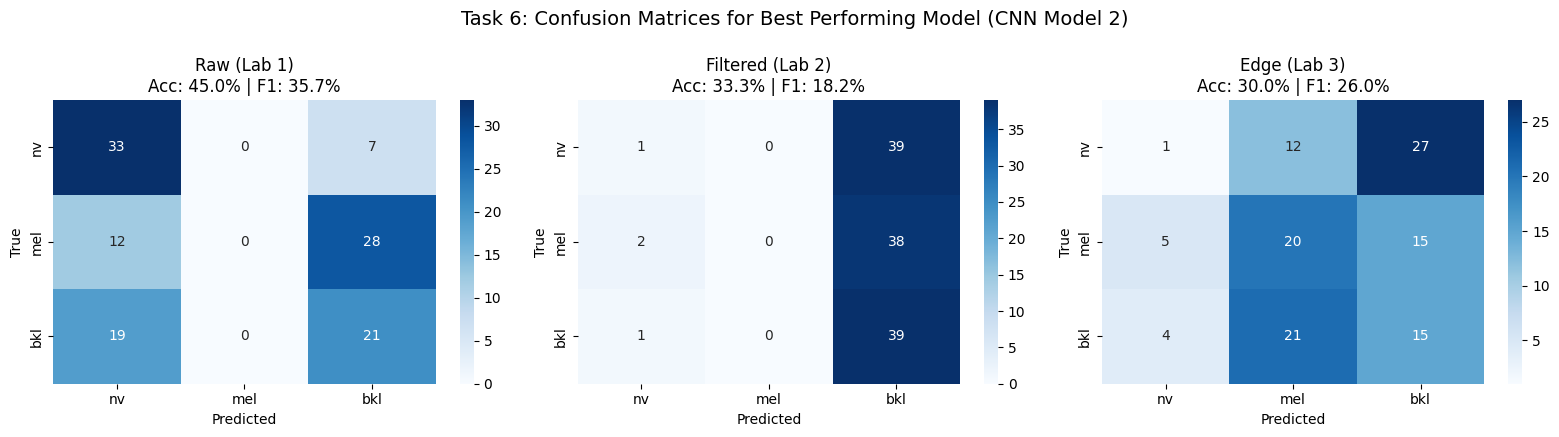

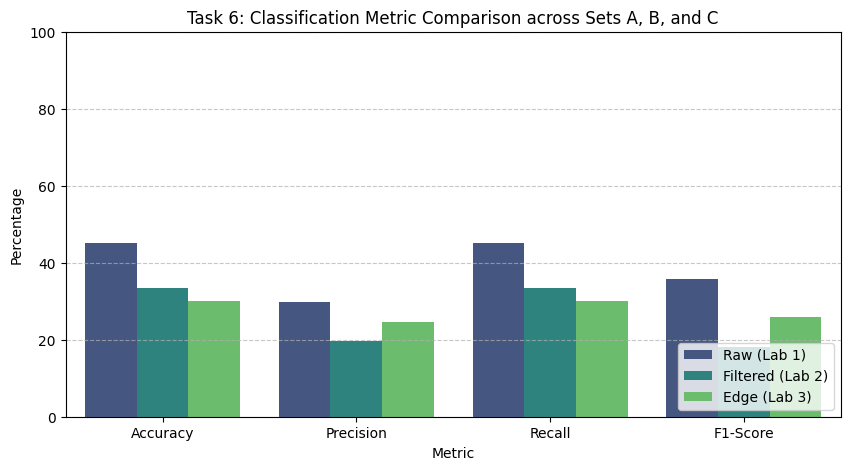

In [10]:
# Cell 6: Task 6 - Visual Comparison of Classification Results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sets = list(best_model_cms.keys())

for idx, set_label in enumerate(sets):
    cm, acc, prec, rec, f1 = best_model_cms[set_label]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=top_classes, yticklabels=top_classes)
    axes[idx].set_title(f"{set_label}\nAcc: {acc:.1f}% | F1: {f1:.1f}%")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True")

plt.tight_layout()
plt.suptitle("Task 6: Confusion Matrices for Best Performing Model (CNN Model 2)", y=1.08, fontsize=14)
plt.show()

# Performance Bar Chart
metrics_df = pd.DataFrame({
    'Representation': sets,
    'Accuracy': [best_model_cms[s][1] for s in sets],
    'Precision': [best_model_cms[s][2] for s in sets],
    'Recall': [best_model_cms[s][3] for s in sets],
    'F1-Score': [best_model_cms[s][4] for s in sets]
}).melt(id_vars='Representation', var_name='Metric', value_name='Percentage')

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Metric', y='Percentage', hue='Representation', palette='viridis')
plt.title("Task 6: Classification Metric Comparison across Sets A, B, and C")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()